# 1 Imports

In [1]:
import joblib
import pandas as pd

import funciones

# Audio de entrada

In [ ]:
audio = 'ruta/al/audio.wav'

## Extraer características

In [ ]:
caracteristicas = funciones.extract_features(audio)
df = pd.DataFrame([caracteristicas])

## Extraer gráficas

# Cargar modelos

In [ ]:
modelo_rf = joblib.load('Jorge/modelo_Random_Forest.pkl')
modelo_lgbm = joblib.load('Jorge/modelo_LightGBM.pkl')
modelo_svm = joblib.load('Jorge/modelo_SVM.pkl')

## Cargar datos de entrenamiento

In [ ]:
X_train = pd.read_csv('datos_entrenamiento.csv')

# Random Forest

## Generar predicciones

In [ ]:
y_pred_rf = modelo_rf.predict(df)
y_pred_proba_rf = modelo_rf.predict_proba(df)[:, 1]

## Generar explicaciones

### SHAP
Hay que ver bien cómo hacer esta función para que funcione ya que usa X_train y X_test (de donde los sacamos)

In [ ]:
funciones.explica_shap(modelo=modelo_rf, )

# LightGBM

## Generar predicciones

In [ ]:
y_pred_lgbm = modelo_lgbm.predict(df)
y_pred_proba_lgbm = modelo_lgbm.predict_proba(df)[:, 1]

# Support Vector Machine

## Generar predicciones

In [ ]:
y_pred_svm = modelo_svm.predict(df)
y_pred_proba_svm = modelo_svm.predict_proba(df)[:, 1]

# WAV2VEC2

Cosas que necesita el modelo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import funciones_wav2vec2

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

In [2]:
# Celda provisional para archivo de audio
audio = "c:\\Users\\ivire\\Documents\\GitHub\\TFG\\tfg-2526-xplicavoz\\Dataset\\Natural\\Inglés\\I_12_N.wav"

## Generar predicciones

In [3]:
funciones_wav2vec2.generar_predicciones(audio)

nombre = I_12_N
Salida del modelo = tensor([[ 0.4330, -0.4596]])
score = 0.2905878722667694


## Generar explicaciones

Preprocesamiento de la entrada

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:04<00:00, 47.08it/s]


`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


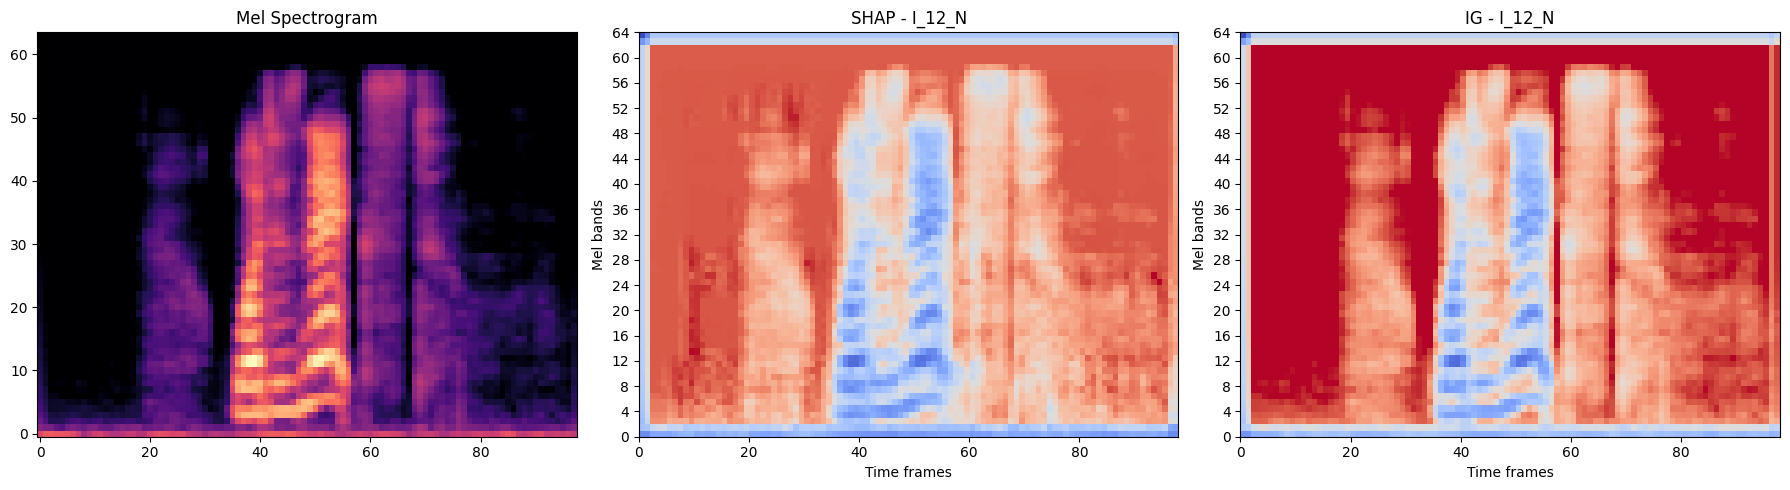

In [4]:
df_train = pd.read_csv("datos_entrenamiento_espectrogramas.csv")
X_tensor = funciones_wav2vec2.preprocesamiento(df_train)
y = df_train["salida_wav2vec2"]
y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

model_espectrogramas = funciones_wav2vec2.build_surrogate()
model_espectrogramas.fit(X_tensor,y_tensor,epochs=50,batch_size=4,verbose=0)

funciones_wav2vec2.mostrar_graficas(model_espectrogramas,audio,X_tensor)

## AASIST

In [ ]:
import torch
from funciones_aux import *

model = torch.jit.load("German/aasist_scripted.pt", map_location="cpu")
model.eval()
audio = r"C:\TFG\Datasets\Propio\Generado\Español\E_1_G.wav"
res = score_audio(audio, model) 
print(res)
aplicar_XAI(wav_path = audio, model = model) 

In [ ]:
import sys
from pathlib import Path
import torch
from funciones_aux import *

device = "cpu"

sys.path.insert(0, str((Path.cwd() / "German").resolve()))

from AASIST import Model

model = torch.load("German/aasist_full.pt", map_location=device, weights_only=False)
model.eval()

print(model.d_args)
print(model.conv_time)
audio = r"C:\TFG\Datasets\Propio\Generado\Español\E_1_G.wav"
res = score_audio(audio, model) 
print(res)
aplicar_XAI(wav_path = audio, model = model) 

{'architecture': 'AASIST', 'nb_samp': 64600, 'first_conv': 128, 'filts': [70, [1, 32], [32, 32], [32, 64], [64, 64]], 'gat_dims': [64, 32], 'pool_ratios': [0.5, 0.7, 0.5, 0.5], 'temperatures': [2.0, 2.0, 100.0, 100.0]}
CONV()
{'logits': tensor([[ 3.9811, -4.0616]]), 'score_bonafide': -4.06155252456665, 'prob_bonafide': 0.0003213507297914475, 'pred_clase': 0}
